In [1]:
# Load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [2]:
df = pd.read_csv("../data/processed/cleaned_default_data.csv")

Baseline MLE (unpenalized) fitted.
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                29965
Model:                          Logit   Df Residuals:                    29941
Method:                           MLE   Df Model:                           23
Date:                Fri, 24 Apr 2026   Pseudo R-squ.:                  0.1207
Time:                        22:39:43   Log-Likelihood:                -13924.
converged:                       True   LL-Null:                       -15836.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.4653      0.017    -88.259      0.000      -1.498      -1.433
LIMIT_BAL     -0.1003      0.020     -4.919      0.000      -0.140      -0.060
SEX           -0.

/Users/dylanli/Credit-Default-Inference-Prediction-1/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/dylanli/Credit-Default-Inference-Prediction-1/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/dylanli/Credit-Default-Inference-Prediction-1/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'pe


Model comparison:
                  model  accuracy  precision    recall        f1   roc_auc
0  Unpenalized Logistic  0.812948   0.726269  0.248115  0.369871  0.715800
2         Lasso (L1) CV  0.813115   0.726872  0.248869  0.370787  0.715786
1         Ridge (L2) CV  0.813115   0.726872  0.248869  0.370787  0.715784

Top 12 features by average absolute coefficient:
           Baseline  Ridge_L2  Lasso_L1
PAY_0      0.650841  0.650475  0.650478
BILL_AMT1 -0.461826 -0.464080 -0.464063
BILL_AMT2  0.276151  0.284690  0.284530
PAY_AMT1  -0.256702 -0.258067 -0.258054
PAY_AMT2  -0.184726 -0.184116 -0.184172
PAY_2      0.109797  0.110289  0.110290
LIMIT_BAL -0.105158 -0.104949 -0.104948
EDUCATION -0.094392 -0.094219 -0.094215
PAY_AMT4  -0.094566 -0.093125 -0.093156
PAY_3      0.084748  0.084149  0.084145
BILL_AMT6  0.091813  0.080750  0.080358
MARRIAGE  -0.078132 -0.078171 -0.078168


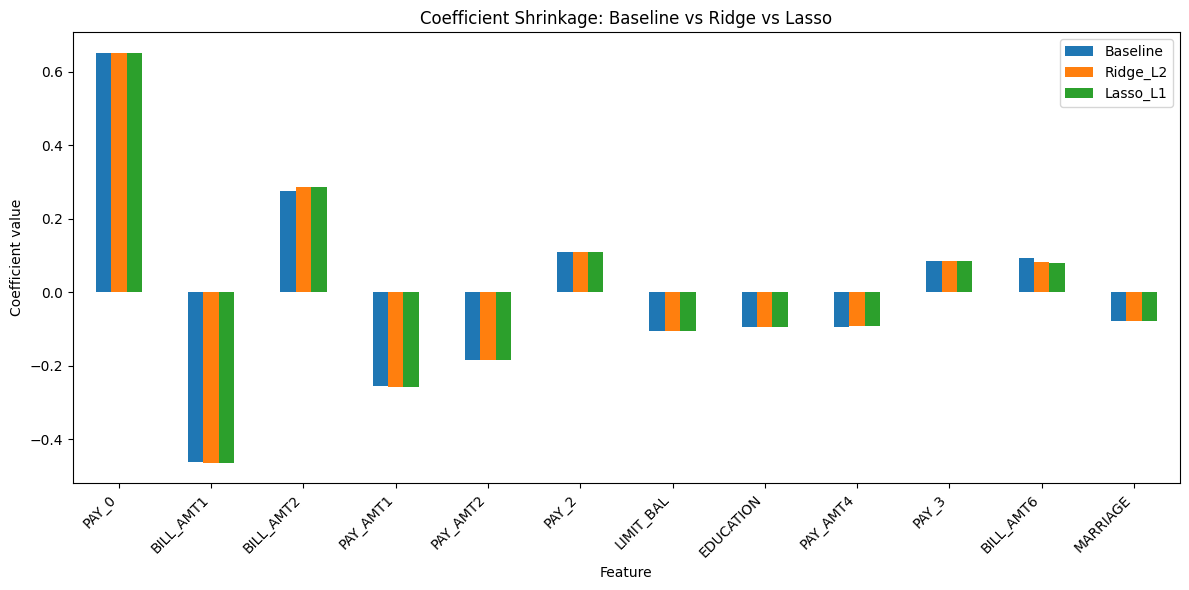


Lasso near-zero coefficients (<1e-3): 0 / 23


In [3]:
df.columns = df.columns.str.strip()

target = "default payment next month"
feature_cols = [col for col in df.columns if col != target]

X = df[feature_cols].values
y = df[target].values

# Scale features (same pattern)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

# ---- Baseline MLE Logistic (same spirit as likelihood_mle.ipynb) ----
X_sm = sm.add_constant(X_scaled_df)
logit_model = sm.Logit(y, X_sm)
mle_result = logit_model.fit(method="newton", maxiter=200, disp=False)

print("Baseline MLE (unpenalized) fitted.")
print(mle_result.summary())

# ---- Train/Test for prediction comparison ----
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

# Baseline sklearn logistic (unpenalized approximation via very large C)
baseline = LogisticRegression(
    penalty="l2", C=1e6, solver="lbfgs", max_iter=5000, random_state=42
)
baseline.fit(X_train, y_train)

# Ridge (L2) with CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
Cs = np.logspace(-3, 2, 20)

ridge_cv = LogisticRegressionCV(
    Cs=Cs, cv=cv, penalty="l2", solver="saga",
    scoring="roc_auc", max_iter=5000, random_state=42, n_jobs=-1
)
ridge_cv.fit(X_train, y_train)

# Lasso (L1) with CV
lasso_cv = LogisticRegressionCV(
    Cs=Cs, cv=cv, penalty="l1", solver="saga",
    scoring="roc_auc", max_iter=5000, random_state=42, n_jobs=-1
)
lasso_cv.fit(X_train, y_train)

def eval_model(name, model, X_te, y_te):
    pred = model.predict(X_te)
    prob = model.predict_proba(X_te)[:, 1]
    return {
        "model": name,
        "accuracy": accuracy_score(y_te, pred),
        "precision": precision_score(y_te, pred, zero_division=0),
        "recall": recall_score(y_te, pred, zero_division=0),
        "f1": f1_score(y_te, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_te, prob),
    }

results = pd.DataFrame([
    eval_model("Unpenalized Logistic", baseline, X_test, y_test),
    eval_model("Ridge (L2) CV", ridge_cv, X_test, y_test),
    eval_model("Lasso (L1) CV", lasso_cv, X_test, y_test),
]).sort_values("roc_auc", ascending=False)

print("\nModel comparison:")
print(results)

# ---- Coefficient shrinkage comparison ----
coef_compare = pd.DataFrame({
    "Baseline": baseline.coef_.ravel(),
    "Ridge_L2": ridge_cv.coef_.ravel(),
    "Lasso_L1": lasso_cv.coef_.ravel()
}, index=feature_cols)

coef_compare["abs_mean"] = coef_compare.abs().mean(axis=1)
coef_compare = coef_compare.sort_values("abs_mean", ascending=False).drop(columns=["abs_mean"])

print("\nTop 12 features by average absolute coefficient:")
print(coef_compare.head(12))

# Plot top coefficients
top_n = 12
coef_compare.head(top_n).plot(kind="bar", figsize=(12, 6))
plt.title("Coefficient Shrinkage: Baseline vs Ridge vs Lasso")
plt.ylabel("Coefficient value")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Optional: sparsity check for Lasso
n_near_zero = (np.abs(coef_compare["Lasso_L1"]) < 1e-3).sum()
print(f"\nLasso near-zero coefficients (<1e-3): {n_near_zero} / {len(feature_cols)}")